In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# El dataset de Boston está disponible en esta URL pública.
data_url="http://lib.stat.cmu.edu/datasets/boston"

In [18]:
raw_df=pd.read_csv(data_url,sep='\s+',skiprows=22, header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2229088645.py:1: SyntaxWarning: invalid escape sequence '\s'
  raw_df=pd.read_csv(data_url,sep='\s+',skiprows=22, header=None)


In [19]:
data=np.hstack([raw_df.values[::2,:],raw_df.values[1::2,:2]])
target=raw_df.values[1::2,2]
feature_names=['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT']
df=pd.DataFrame(data,columns=feature_names)
df['PRICE']= target

In [20]:
print('---PRIMERAS 5 FILAS---')
print(df.head())

print('\n---RESUMEN TÉCNICO---')
df.info()

print('\n---RESUMEN ESTADÍSTICO---')
print(df.describe())

---PRIMERAS 5 FILAS---
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  

---RESUMEN TÉCNICO---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS 

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

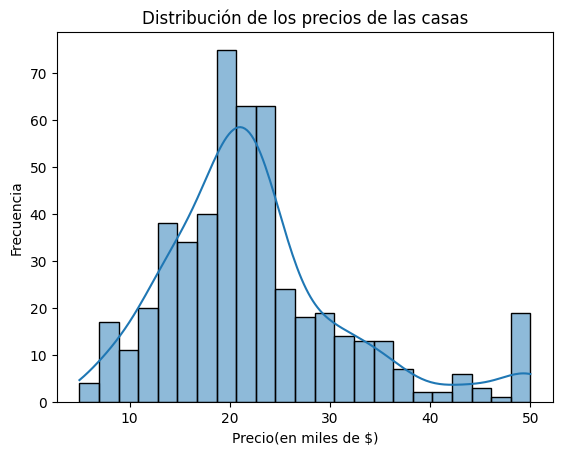

In [22]:
#Creamos un histograma para la columna PRECIO
sns.histplot(df['PRICE'],kde=True)

#Añadimos título para mayor claridad
plt.title('Distribución de los precios de las casas')
plt.xlabel('Precio(en miles de $)')
plt.ylabel('Frecuencia')

plt.show()

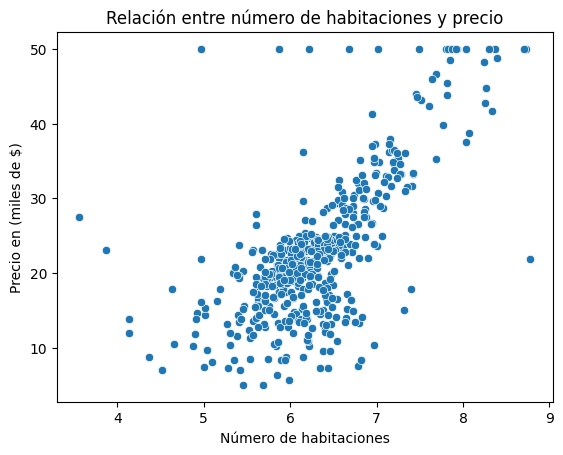

In [23]:
# El sentido común nos dice que las casas con más habitaciones deberían ser más caras. ¡Vamos a comprobarlo!
# Creamos un diagrama de dispersión entre RM (rooms-habitaciones) y PRICE

sns.scatterplot(x=df['RM'],y=df['PRICE'])

plt.title('Relación entre número de habitaciones y precio')
plt.xlabel('Número de habitaciones')
plt.ylabel('Precio en (miles de $)')

plt.show()

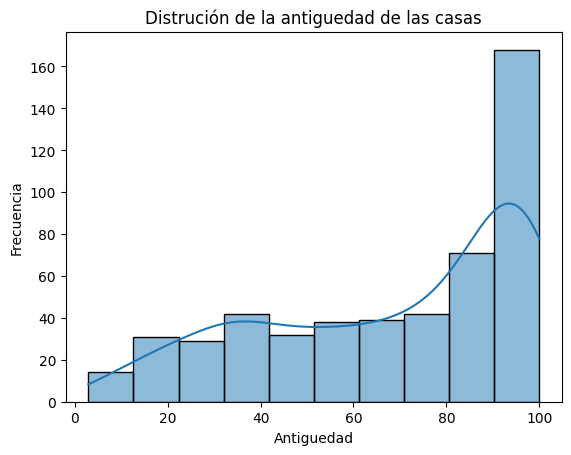

In [24]:
sns.histplot(df['AGE'],kde=True)

plt.title('Distrución de la antiguedad de las casas')
plt.xlabel('Antiguedad')
plt.ylabel('Frecuencia')

plt.show()

La mayoría de las casas son viejas

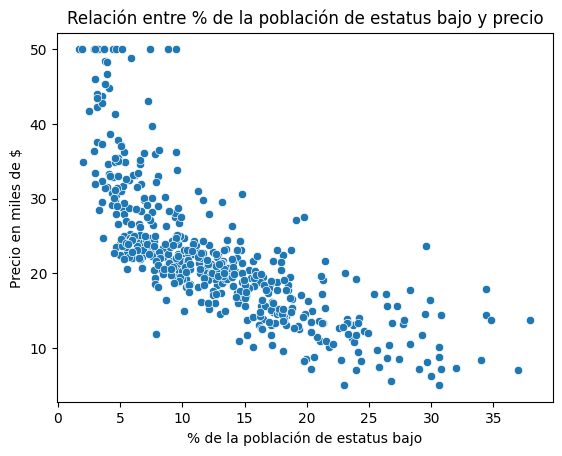

In [25]:
sns.scatterplot(x=df['LSTAT'],y=df['PRICE'])

plt.title('Relación entre % de la población de estatus bajo y precio')
plt.xlabel('% de la población de estatus bajo')
plt.ylabel('Precio en miles de $')

plt.show()

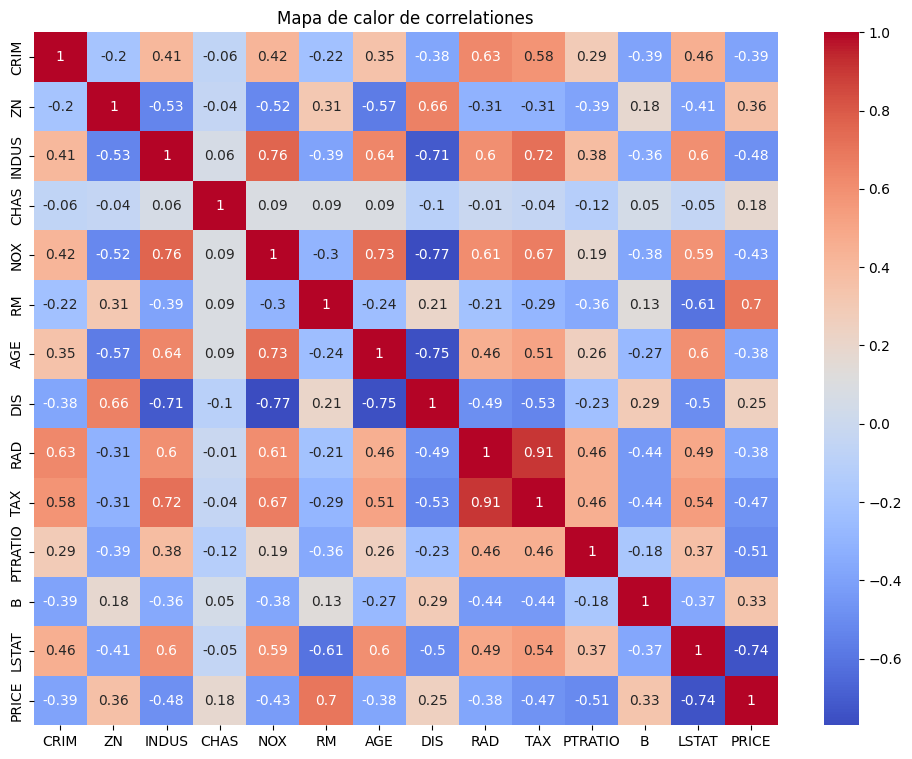

In [31]:
#1. Calcular la matriz de correlación

correlation_matrix=df.corr().round(2) #.round(2) redondea los números

#Crear el mapa de calor
plt.figure(figsize=(12,9))#hacemos la figura grande para poder leerla mejor
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Mapa de calor de correlationes')
plt.show()

1er Modelo de regresion

In [43]:
from sklearn.model_selection import train_test_split
#Dividimos los datos: test_size=0.2 que significa que el 20% de los datos serán para la prueba
#random_state=42 asegura que la división sea siempre la misma cada vez que ejecutamos el código

y = df['PRICE']
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")

Tamaño del conjunto de entrenamiento (X_train): (404, 2)
Tamaño del conjunto de prueba (X_test): (102, 2)


In [36]:
from sklearn.linear_model import LinearRegression

In [44]:
modelo=LinearRegression() #Creamos una instancia del modelo, un 'cerebro'vacío
modelo.fit(X_train, y_train) #El modelo ha aprendido. Ha encontrado los "coeficientes" óptimos para `LSTAT` y `RM` que le permiten predecir `PRICE`.

print("Modelo entrenado exitosamente")


Modelo entrenado exitosamente


In [38]:
predicciones=modelo.predict(X_test)

In [45]:
#Comparando los resultados
comparacion=pd.DataFrame({'Precio real': y_test.head(),'Precio Predicho': predicciones[:5].round(2)})
print('\nComparación de los primeros cinco resultados')
print(comparacion)


Comparación de los primeros cinco resultados
     Precio real  Precio Predicho
173         23.6            25.51
274         32.4            30.86
491         13.6            17.43
72          22.8            25.81
452         16.1            19.65


In [46]:
from sklearn.metrics import mean_absolute_error, r2_score

Procedemos a calcular el MAE y el R2

In [47]:
#Calculamos el Error Absoluto Medio
mae=mean_absolute_error(y_test,predicciones)

#Calculamos el R-cuadrado
r2=r2_score(y_test, predicciones)

In [49]:
print('---Evaluación final del modelo---')
print(f'Error Absoluto Medio (MAE): ${mae:.2f} (miles de dólares)')
print(f'R-cuadrado:{r2:.2f}')
print('\n Interpretación:')
print(f'En promedio, nuestro modelo se equivoca en ${mae*1000:,.2f} al predecir el precio de una casa')
print(f'Nuestro modelo explica el {r2:.0%} de la variabilidad en los precios de las casas usando solo las características RM y LSTAT')

---Evaluación final del modelo---
Error Absoluto Medio (MAE): $3.90 (miles de dólares)
R-cuadrado:0.57

 Interpretación:
En promedio, nuestro modelo se equivoca en $3,898.76 al predecir el precio de una casa
Nuestro modelo explica el 57% de la variabilidad en los precios de las casas usando solo las características RM y LSTAT
